# Why Use K-Means Clustering?

K-Means is popular in a wide variety of applications due to its simplicity, efficiency, and effectiveness. Here's why it is widely used:

- **Data Segmentation**: One of the most common uses of K-Means is segmenting data into distinct groups. For example, businesses use K-Means to group customers based on behavior, such as purchasing patterns or website interactions.

- **Image Compression**: K-Means can be used to reduce the complexity of images by grouping similar pixels into clusters, effectively compressing the image. This is useful for image storage and processing.

- **Anomaly Detection**: K-Means can be applied to detect anomalies or outliers by identifying data points that do not belong to any of the clusters.

- **Document Clustering**: In natural language processing (NLP), K-Means is used to group similar documents or articles together. It's often used in applications like recommendation systems or news categorization.

- **Organizing Large Datasets**: When dealing with large datasets, K-Means can help organize the data into smaller, more manageable chunks based on similarities, improving the efficiency of data analysis.

# Implementation of K-Means Clustering

# Understanding K-Means++

### What is K-Means++?

K-Means++ is an improvement over standard K-Means. The only difference is in how we choose the initial cluster centers (centroids).

**Standard K-Means:** Chooses k random points as initial centroids. Sometimes this can lead to bad results because random points might be close to each other.

**K-Means++:** Chooses initial centroids in a smart way:
1. Pick the first centroid randomly
2. Pick each next centroid by choosing a point that is far away from already chosen centroids
3. This gives K-Means a better starting point to find good clusters

## Simple Example

Imagine 5 points on a line: **2, 3, 8, 9, 10**

We want 2 clusters.

**Bad start (Random):** 
- Centroid 1 = 2
- Centroid 2 = 3
- Both are close together! This is not a good start.

**Good start (K-Means++):**
- Centroid 1 = 2 (chosen randomly first)
- Centroid 2 = 9 (chosen because it's far from 2)
- Now we have a good starting point!

Result: K-Means++ usually needs fewer iterations and finds better clusters.

## What is make_blobs()?

`make_blobs()` is a function from scikit-learn that creates sample data with blob-shaped clusters. It's useful for testing machine learning algorithms.

**Parameters:**
- `n_samples=300`: Number of data points to generate
- `centers=4`: Number of clusters (blob centers) to create
- `n_features=2`: Number of dimensions/features (we use 2 for easy visualization)
- `cluster_std=0.8`: Standard deviation of each cluster (how spread out the points are)
- `random_state=42`: Seed for reproducibility (same data every time)

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

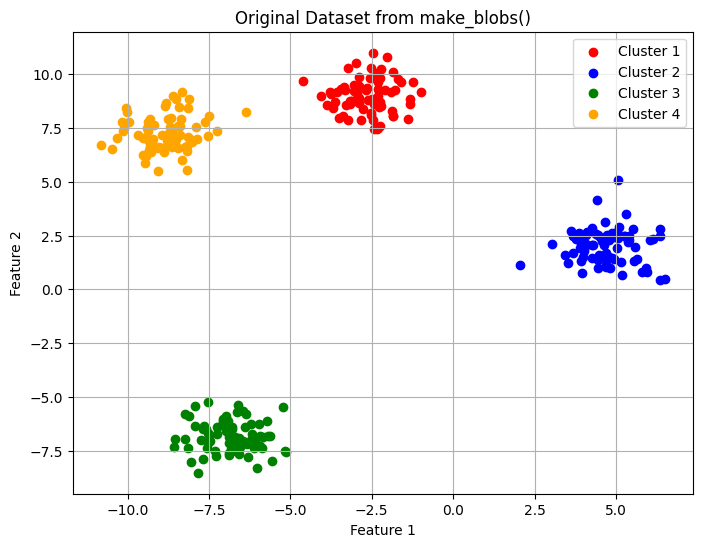

In [70]:
# Generate sample dataset with 4 clusters
np.random.seed(42)
X, y_true = make_blobs(n_samples=300, centers=4, n_features=2, cluster_std=0.8, random_state=42)

# Plot the original data
plt.figure(figsize=(8, 6))
colors_orig = ['red', 'blue', 'green', 'orange']

for i in range(4):
    points = X[y_true == i]
    plt.scatter(points[:, 0], points[:, 1], c=colors_orig[i], label='Cluster ' + str(i+1))

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original Dataset from make_blobs()')
plt.legend()
plt.grid(True)
plt.show()

In [71]:
# Apply K-Means clustering with k=4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)

# Fit the model and get cluster labels
cluster_labels = kmeans.fit_predict(X)

# Get cluster centers
centers = kmeans.cluster_centers_
print("Centers of clusters: ", centers)

print("Cluster Results:")

# Inertia: Sum of squared distances from each point to its nearest centroid
# Lower inertia = tighter, more compact clusters (better clustering)
print("Number of clusters:", kmeans.n_clusters) 
print("Inertia:", kmeans.inertia_)
print("Number of iterations:", kmeans.n_iter_)

Centers of clusters:  [[-2.63715917  8.98563949]
 [-6.84180708 -6.84038791]
 [ 4.70253968  2.02807134]
 [-8.83330596  7.21790214]]
Cluster Results:
Number of clusters: 4
Inertia: 362.47243882770385
Number of iterations: 3


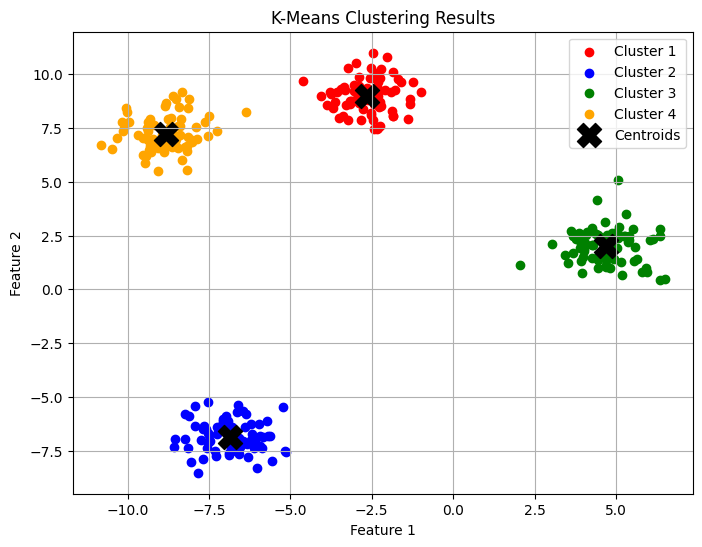

In [72]:
# Plot the clusters
colors = ['red', 'blue', 'green', 'orange']

plt.figure(figsize=(8, 6))

# Plot each cluster
for i in range(4):
    points = X[cluster_labels == i]
    plt.scatter(points[:, 0], points[:, 1], c=colors[i], label='Cluster ' + str(i+1))

# Plot centroids
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=300, c='black', label='Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering Results')
plt.legend()
plt.grid(True)
plt.show()

k=1, Inertia=19780.25
k=2, Inertia=9211.21
k=3, Inertia=1919.36
k=4, Inertia=362.47
k=5, Inertia=329.27
k=6, Inertia=294.63
k=7, Inertia=261.56
k=8, Inertia=232.01
k=9, Inertia=210.01


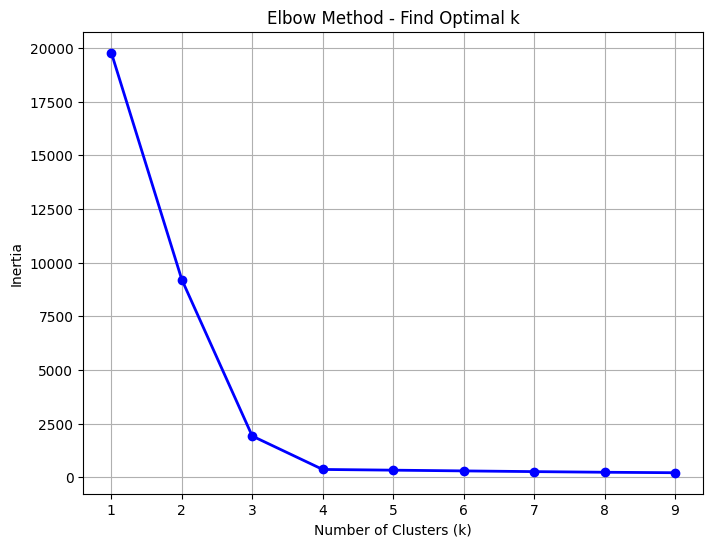

In [73]:
# Find optimal number of clusters using Elbow Method
inertias = []
k_values = range(1, 10)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_temp.fit(X)
    inertias.append(kmeans_temp.inertia_)

for k, inertia in zip(k_values, inertias):
    print(f"k={k}, Inertia={inertia:.2f}")

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Find Optimal k')
plt.grid(True)
plt.show()

In [74]:
# Test with new data points
new_points = np.array([[5, 5], [-5, -5], [5, -5]])
predictions = kmeans.predict(new_points)

print("Predictions for new points:")
for i in range(len(new_points)):
    print("Point", new_points[i], "-> Cluster", predictions[i])

Predictions for new points:
Point [5 5] -> Cluster 2
Point [-5 -5] -> Cluster 1
Point [ 5 -5] -> Cluster 2


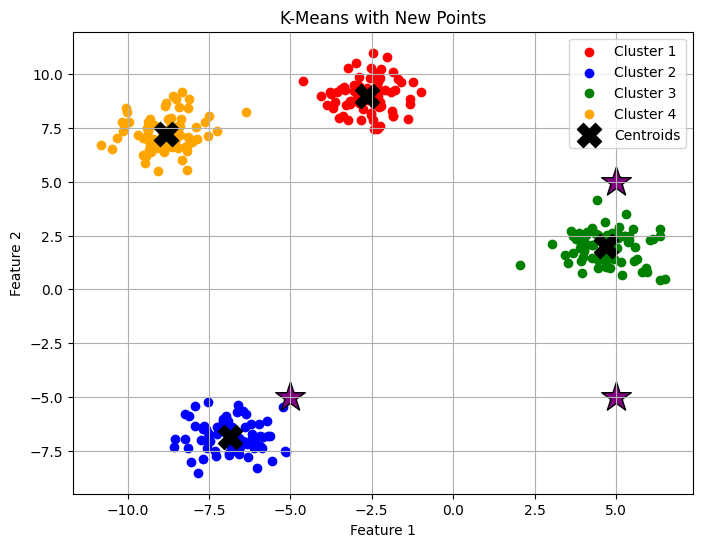

In [75]:
# Plot clusters with new points
plt.figure(figsize=(8, 6))

# Plot clusters
for i in range(4):
    points = X[cluster_labels == i]
    plt.scatter(points[:, 0], points[:, 1], c=colors[i], label='Cluster ' + str(i+1))

# Plot centroids
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=300, c='black', label='Centroids')

# Plot new points
for i in range(len(new_points)):
    plt.scatter(new_points[i, 0], new_points[i, 1], marker='*', s=500, c='purple', edgecolors='black')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means with New Points')
plt.legend()
plt.grid(True)
plt.show()

## Summary

**What we learned:**
- K-Means groups data into k clusters
- Each point belongs to the nearest centroid
- K-Means++ improves the initialization to avoid bad starting points
- Elbow Method helps find the best number of clusters
- We can predict which cluster new points belong to